In [2]:
import Pkg
using RCall
using Random
using DataFrames, DataFramesMeta
using Revise
using CSV
using StatsBase
using Statistics
using Arrow

In [3]:
base_name = "multiple_runs14"
run_date = "20250204"
figure_export_dir = "./exp/$(base_name)/figs/Compare_with_previous_studies"
data_export_dir = "./exp/$(base_name)/data/ins_del_analysis"
base_dir = "exp/$(base_name)"
rdata_dir = "rdata/$(run_date)_ins_del_analysis.RData"
misc_dir = "../misc"
base_dir_event_classification = joinpath(base_dir, "export/classify_IS_events")
file_prefix = "$(run_date)_"

mkpath(figure_export_dir)
mkpath(data_export_dir)
mkpath("rdata")
mkpath(misc_dir)

@rput figure_export_dir
@rput data_export_dir
@rput base_dir
@rput rdata_dir
@rput misc_dir
@rput base_dir_event_classification
@rput file_prefix
R"""
Sys.setlocale("LC_COLLATE","C") # order by dictionary order
library(tidyverse)
library(cowplot)
library(latex2exp)
library(stats)
library(scales)
library(lemon)
library(gghalves)
library(ggbeeswarm)
library(ggpointdensity)
library(viridis)
library(forcats)
library(MASS)
library(sfsmisc)
library(ggnewscale)
library(ggrastr)
library(car)
library(arrow)
library(fitdistrplus)
cbp <- c("#999999", "#E69F00", "#56B4E9", "#009E73", 
                       "#F0E442", "#0072B2", "#D55E00", "#CC79A7")
select <- dplyr::select
filter <- dplyr::filter
lag <- dplyr::lag
""";

┌ Warning: RCall.jl: ── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
│ ✔ dplyr     1.1.3     ✔ readr     2.1.4
│ ✔ forcats   1.0.0     ✔ stringr   1.5.0
│ ✔ ggplot2   3.4.3     ✔ tibble    3.2.1
│ ✔ lubridate 1.9.2     ✔ tidyr     1.3.0
│ ✔ purrr     1.0.2     
│ ── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
│ ✖ dplyr::filter() masks stats::filter()
│ ✖ dplyr::lag()    masks stats::lag()
│ ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: 
│ Attaching package: ‘cowplot’
│ 
│ The following object is masked from ‘package:lubridate’:
│ 
│     stamp
│ 
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: 
│ Attaching package: ‘scales’
│ 
│ The following object is masked from ‘package:purrr’:
│ 
│     discard
│ 
│ The following object is masked from ‘package:readr’:
│ 
│     co

## Colony sizes
colony sizes are measured only when out of range (2-3).

In [4]:
R"""
col_size_raw <- read_csv("../misc/IS_Exp_Colony_Size_Tarusawa.csv")
head(col_size_raw, 2)
"""

┌ Warning: RCall.jl: Rows: 44 Columns: 24
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: ","
│ dbl (24): ID, RecA, Line, Subline, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13...
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 2 × 24
     ID  RecA  Line Subline   `1`   `2`   `3`   `4`   `5`   `6`   `7`   `8`
  <dbl> <dbl> <dbl>   <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>
1     1     1     1       1    NA    NA    NA    NA    NA    NA    NA    NA
2     2     1     1       2    NA    NA    NA    NA    NA    NA    NA    NA
# ℹ 12 more variables: `9` <dbl>, `10` <dbl>, `11` <dbl>, `12` <dbl>,
#   `13` <dbl>, `14` <dbl>, `15` <dbl>, `16` <dbl>, `17` <dbl>, `18` <dbl>,
#   `19` <dbl>, `20` <dbl>


In [5]:
R"""
col_size_raw %>% select(matches("[[:digit:]]"))
"""

RObject{VecSxp}
# A tibble: 44 × 20
     `1`   `2`   `3`   `4`   `5`   `6`   `7`   `8`   `9`  `10`  `11`  `12`  `13`
   <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>
 1    NA    NA    NA    NA    NA    NA    NA    NA    NA  NA      NA    NA   3.1
 2    NA    NA    NA    NA    NA    NA    NA    NA    NA  NA      NA    NA  NA  
 3    NA    NA    NA    NA    NA    NA    NA    NA    NA  NA      NA    NA  NA  
 4    NA    NA    NA    NA    NA    NA    NA    NA    NA  NA      NA    NA  NA  
 5    NA    NA    NA    NA    NA    NA    NA    NA    NA  NA      NA    NA  NA  
 6    NA    NA    NA    NA    NA    NA    NA    NA    NA  NA      NA    NA  NA  
 7    NA    NA    NA    NA    NA    NA    NA    NA    NA   3.5    NA    NA  NA  
 8    NA    NA    NA    NA    NA    NA    NA    NA    NA  NA      NA    NA  NA  
 9    NA    NA    NA    NA    NA    NA    NA    NA    NA  NA      NA    NA  NA  
10    NA    NA    NA    NA    NA    NA    NA    NA    NA  NA      NA    N

In [6]:
R"""
col_size_tidy <- col_size_raw %>% pivot_longer(cols = matches("[[:digit:]]"), names_to = "Round", values_to = "size") %>%
	mutate(Round = as.numeric(Round))
col_size_tidy %>% filter(Round == 1, !is.na(size))
"""

RObject{VecSxp}
# A tibble: 7 × 6
     ID  RecA  Line Subline Round  size
  <dbl> <dbl> <dbl>   <dbl> <dbl> <dbl>
1    13     1     4       1     1   3.5
2    14     1     4       2     1   4.3
3    15     1     4       3     1   3.3
4    26     0     7       2     1   1.8
5    28     0     7       4     1   1.5
6    29     0     8       1     1   1.7
7    30     0     8       2     1   1.9


┌ Warning: RCall.jl: Warning: Removed 743 rows containing missing values (`geom_point()`).
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Warning: Removed 743 rows containing missing values (`geom_point()`).
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


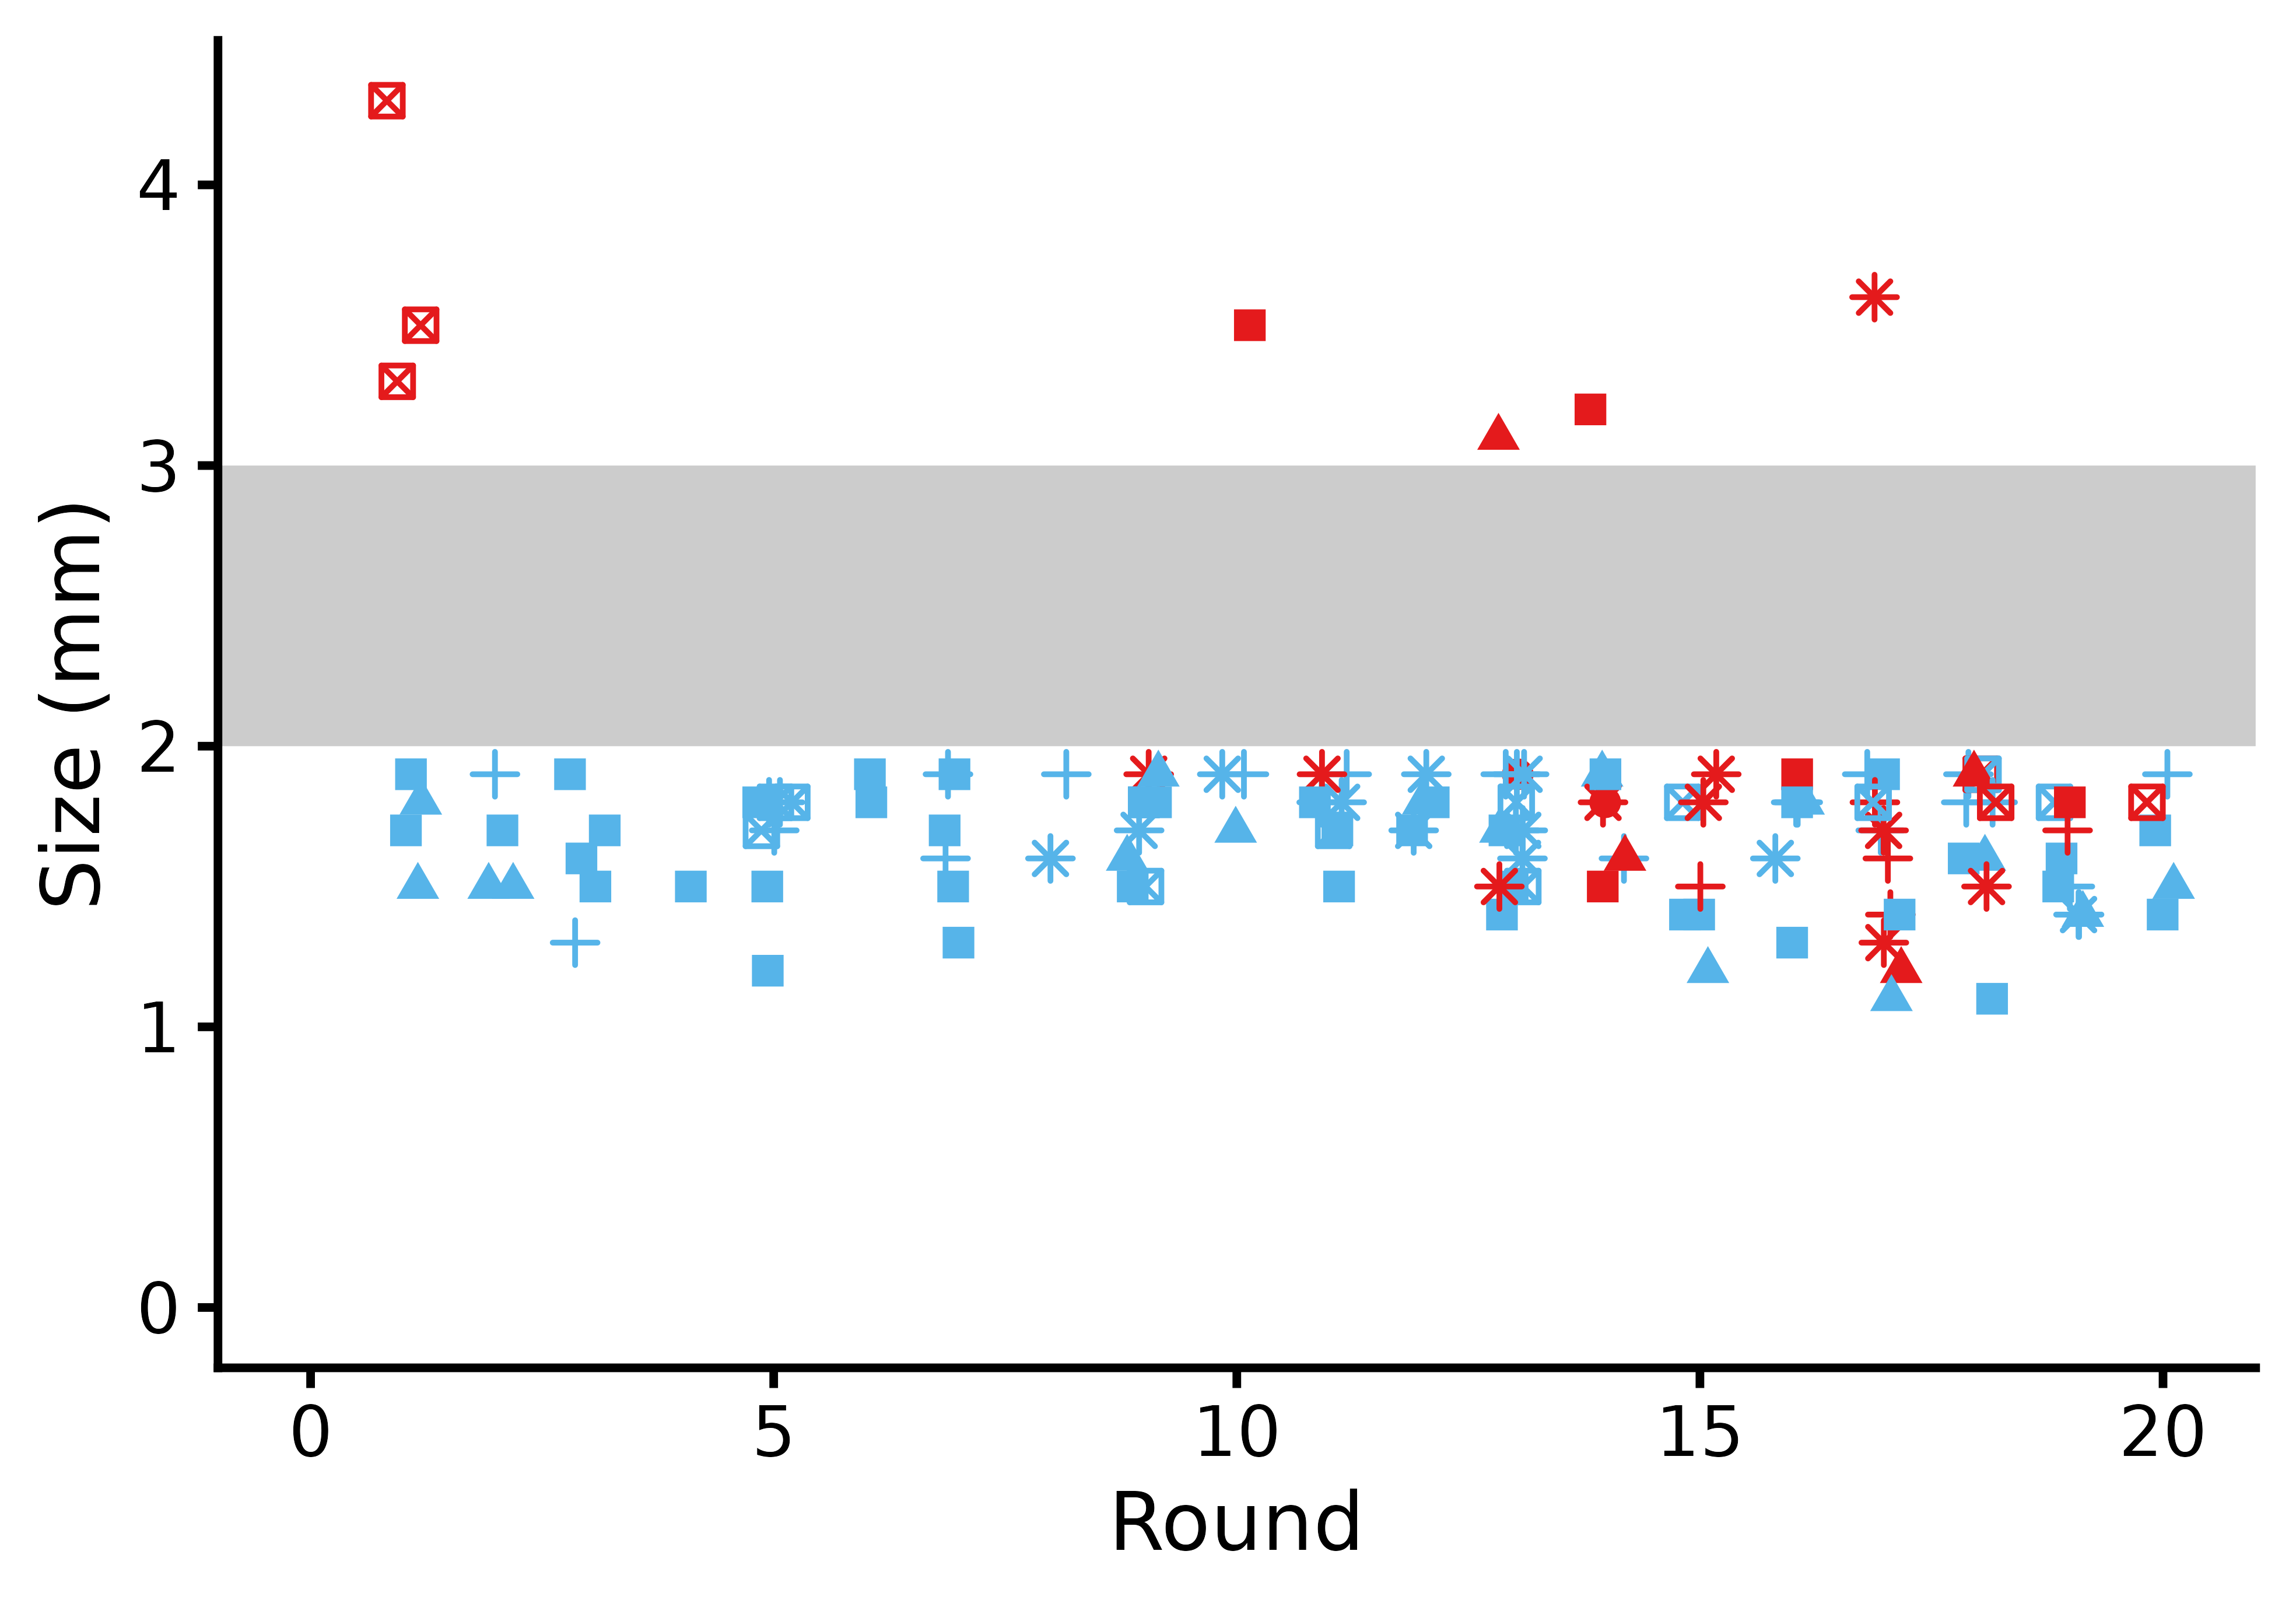

In [10]:
figure_name = file_prefix * "colony_size"
@rput figure_name
R"""
p <- 
  ggplot() + 
  geom_jitter(data  = col_size_tidy %>% slice(sample(1:n())),
  	aes(x = Round, y = size, color = RecA==0, shape = as.factor(Line %% 6)),
  	height = 0, width = 0.2) +
  #scale_color_brewer(palette = "Set1") +
  scale_color_manual(values = c("#e41a1c", "#56b4e9")) +
  labs(x = "Round", y = "Size (mm)", color = "RecA") +
  geom_rect(data = data.frame(), aes(xmin = -10, xmax = 30, ymin = 2, ymax = 3), fill = "black", alpha = 0.2) + 
  guides(shape = "none", color = "none")+
  theme_half_open(10) +
  coord_cartesian(xlim = c(0, 20)) + 
  ylim(0, NA)

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=10, height=7, units="cm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=10, height=7, units="cm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))


┌ Warning: RCall.jl: Warning: Removed 743 rows containing missing values (`geom_point()`).
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Warning: Removed 743 rows containing missing values (`geom_point()`).
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


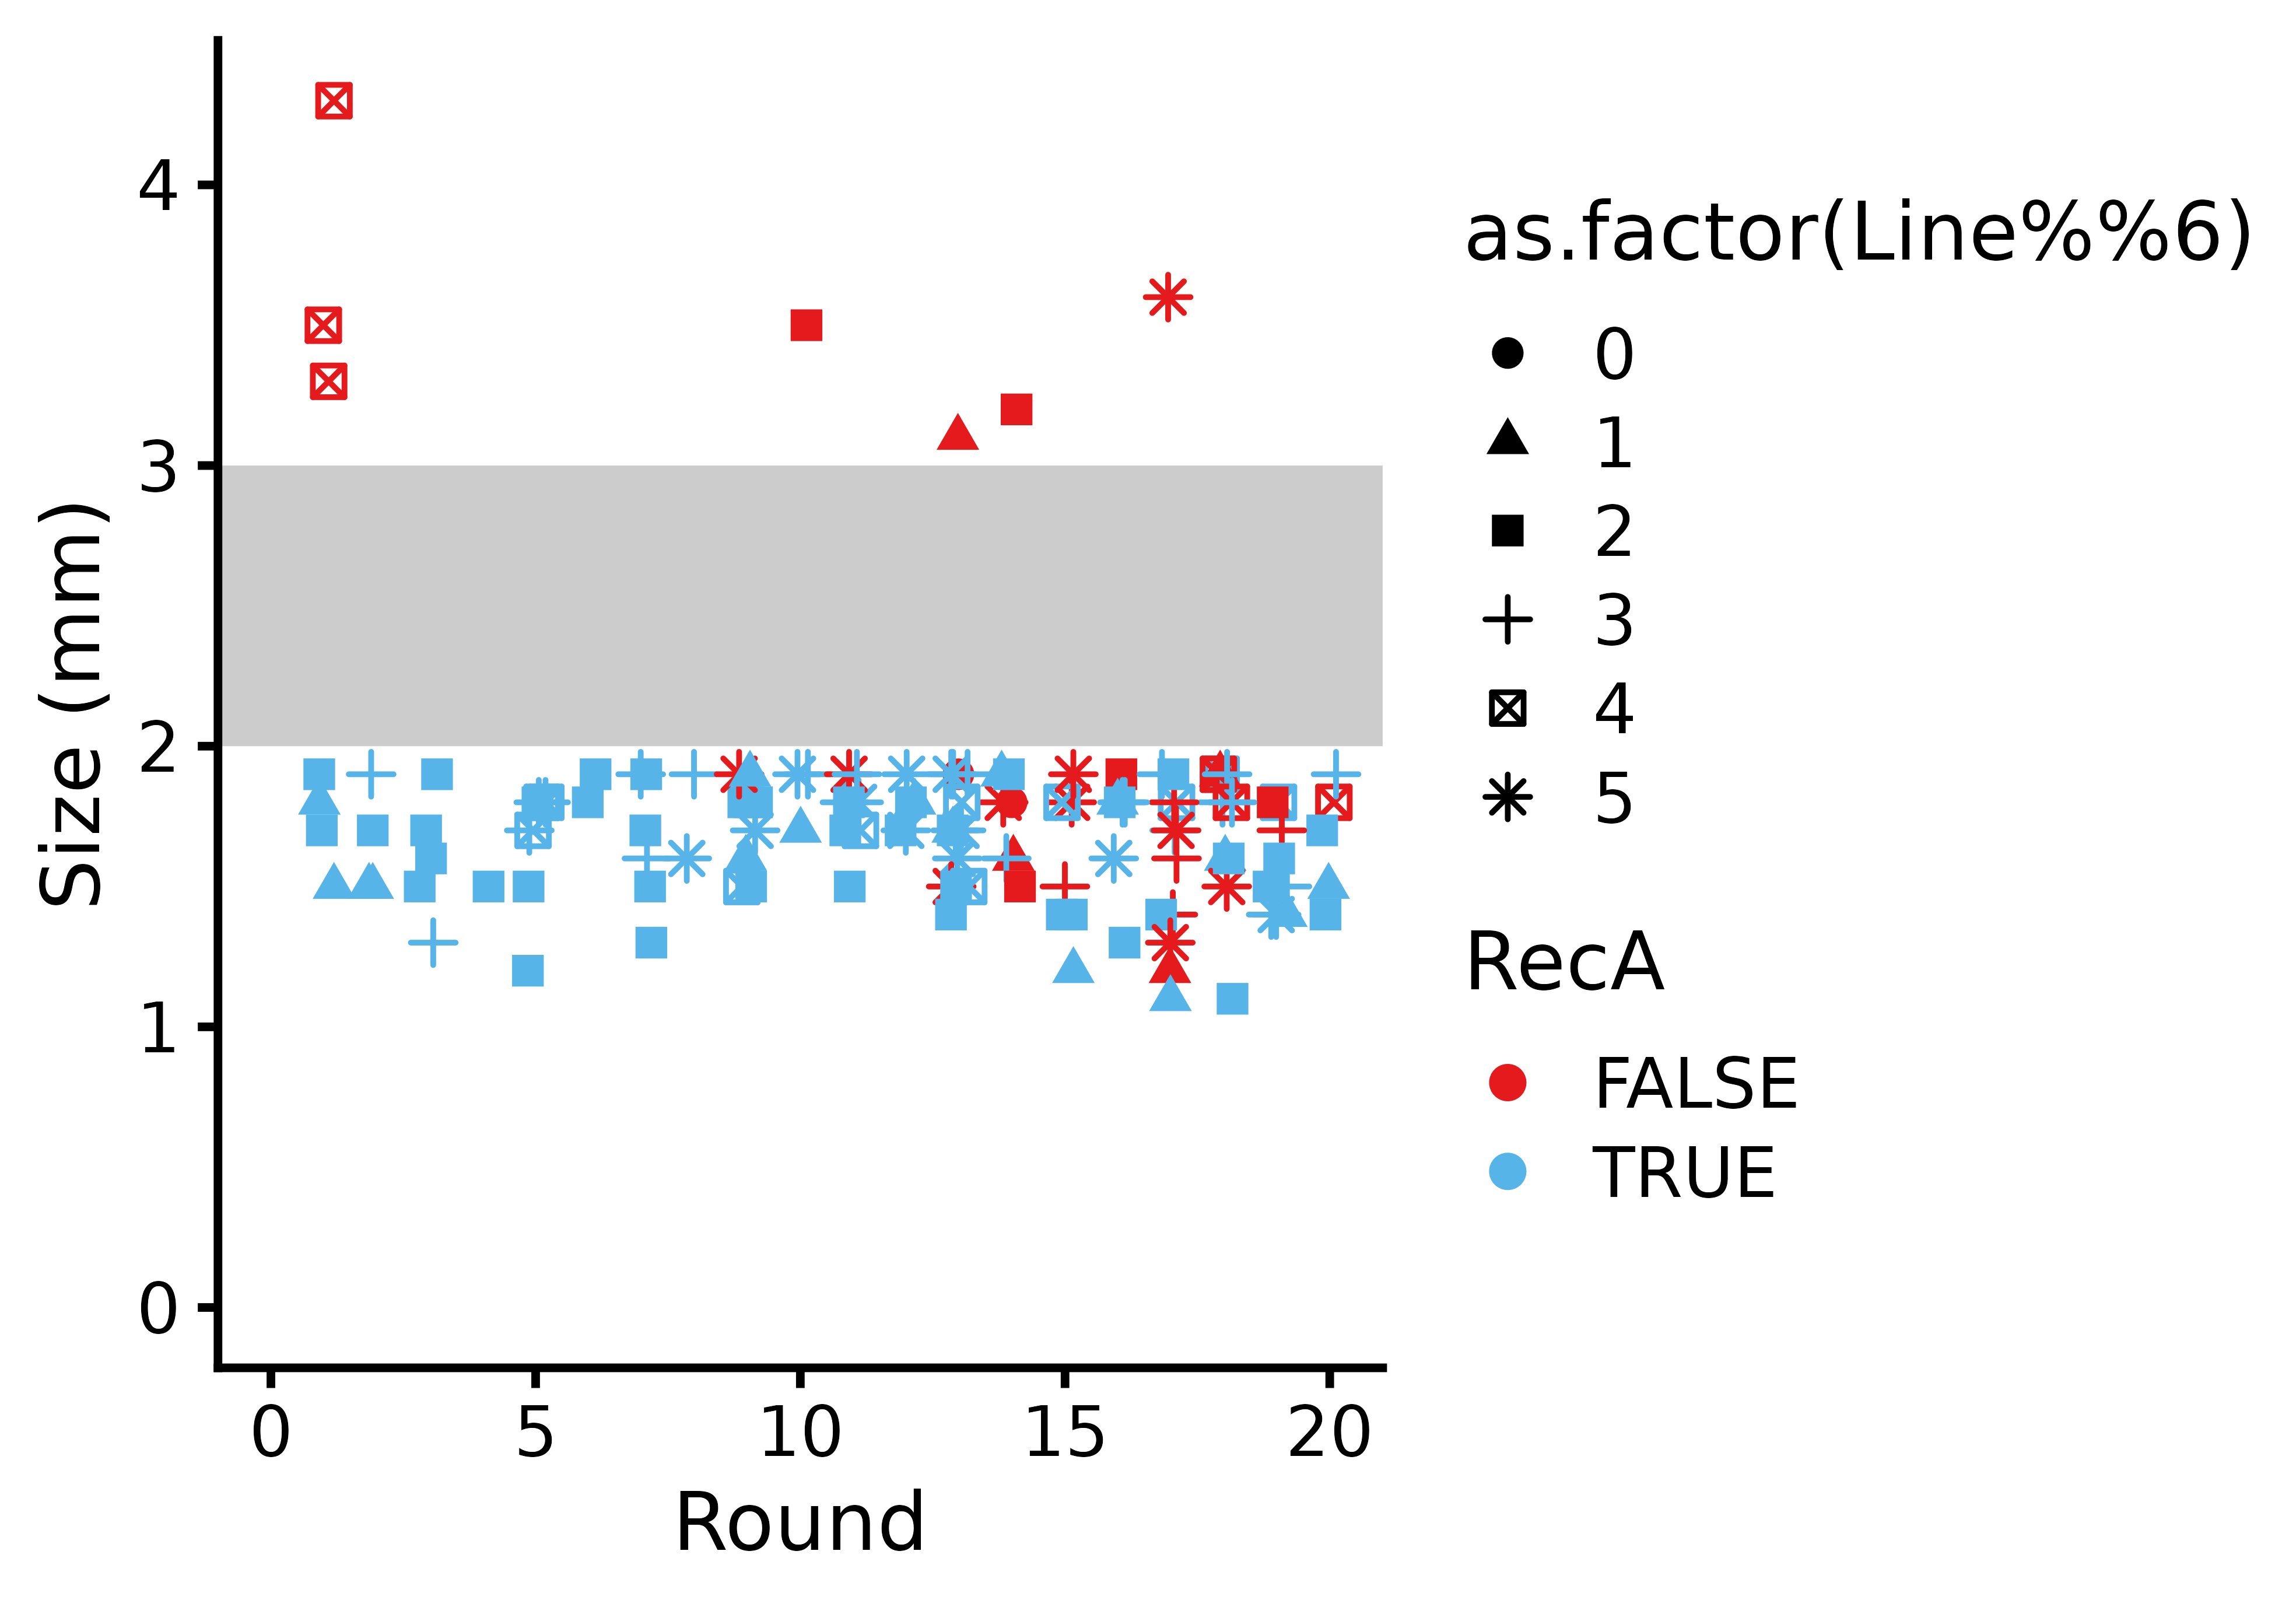

In [14]:
figure_name = file_prefix * "colony_size_guide"
@rput figure_name
R"""
p <- 
  ggplot() + 
  geom_jitter(data  = col_size_tidy %>% slice(sample(1:n())),
  	aes(x = Round, y = size, color = RecA==0, shape = as.factor(Line %% 6)),
  	height = 0, width = 0.2) +
  #scale_color_brewer(palette = "Set1") +
  scale_color_manual(values = c("#e41a1c", "#56b4e9")) +
  labs(x = "Round", y = "Size (mm)", color = "RecA") +
  geom_rect(data = data.frame(), aes(xmin = -10, xmax = 30, ymin = 2, ymax = 3), fill = "black", alpha = 0.2) + 
  #guides(shape = "none", color = "none")+
  theme_half_open(10) +
  coord_cartesian(xlim = c(0, 20)) + 
  ylim(0, NA)

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=10, height=7, units="cm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=10, height=7, units="cm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))


In [60]:
# percentage of colonies in 1.5mm-3.0  mm range
R"""
col_size_tidy %>% 
	mutate(size = ifelse(is.na(size), 2.5, size)) %>%
	summarise(n = sum((size >=1.5) & (size <=3.0)),
		N = n()) %>% mutate(p = n/N)
"""

RObject{VecSxp}
# A tibble: 1 × 3
      n     N     p
  <int> <int> <dbl>
1   855   880 0.972


# Del-dup fig
Incorporate the information about the type of duplications. 

In [3]:
R"""
min_del_threshold <- 100
depth_interval_df.evo <- read_csv(file.path(base_dir, "export/classify_IS_events/depth_interval.csv"))
depth_interval_df.evo <- depth_interval_df.evo %>% filter(length >= min_del_threshold) %>%
	filter(!((line == "L04-1") & (gen_id == 3))) %>%
	# remove a "deletion" of a composite transposon. This composite transposition did not happen in the next generation so it is considered false positive.
	filter(!((line == "L05-4") & (gen_id == 3) & (3.2e6 < start_fix) & (end_fix < 3.4e6) & (depth == 0) & (length > 1e4))) 
depth_interval_df.evo %>% head(2)
"""

┌ Warning: RCall.jl: Rows: 914 Columns: 11
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: ","
│ chr  (1): line
│ dbl (10): group, start, end, depth, length, start_fix, end_fix, is_start, is...
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 2 × 11
  group  start    end depth length start_fix end_fix is_start is_end line 
  <dbl>  <dbl>  <dbl> <dbl>  <dbl>     <dbl>   <dbl>    <dbl>  <dbl> <chr>
1     1      1 549437     1 549437         1  552530       -1      3 L01-1
2     2 549438 554384     0   4947    552531  560570        3      6 L01-1
# ℹ 1 more variable: gen_id <dbl>


In [4]:
R"""
depth_interval_df.evo.annotated <- read_csv(file.path(base_dir, "data/ins_del_analysis/20250216_depth_interval_annotated.csv")) %>%
	filter(length >= min_del_threshold) %>% filter(!((line == "L04-1") & (gen_id == 3))) %>%
	filter(Include == 1)
depth_interval_df.evo.annotated %>% head(2)
"""

┌ Warning: RCall.jl: Rows: 42 Columns: 17
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: ","
│ chr  (3): group, line, Note
│ dbl (14): start, end, depth, length, start_fix, end_fix, is_start, is_end, g...
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 2 × 17
  group   start     end depth length start_fix end_fix is_start is_end line 
  <chr>   <dbl>   <dbl> <dbl>  <dbl>     <dbl>   <dbl>    <dbl>  <dbl> <chr>
1 4     1934346 1967835     2  33490   1952960 1991112       16     17 L01-1
2 4      565110  581275     2  16166    571296  587461        6      7 L01-2
# ℹ 7 more variables: gen_id <dbl>, recA <dbl>, Include <dbl>, IS <dbl>,
#   Trans <dbl>, Tandem <dbl>, Note <chr>


In [5]:
R"""
depth_interval_df.evo.del <- 
	depth_interval_df.evo %>%
	filter(!((line == "L04-1") & (gen_id == 3))) %>%
	filter(depth == 0) %>%
	mutate(Type = ifelse(depth == 0, "Deletion", "Duplication")) %>%
	mutate(RecA = ifelse(as.numeric(str_sub(line, start=2, end = 3))<=6, "recA+", "recA\U2212")) %>%
	mutate(IS = ifelse(is_start != -1 | is_end != -1, "IS", "Non-IS")) %>%
	mutate(dup_type = factor(IS, levels = c("Non-IS", "IS"))) %>%
	select(line, gen_id, length, depth, Type, RecA, IS, dup_type)

depth_interval_df.evo.annotated.dup <-
	depth_interval_df.evo.annotated %>%
	filter(depth > 1) %>%
	mutate(RecA = ifelse(as.numeric(str_sub(line, start=2, end = 3))<=6, "recA+", "recA\U2212")) %>%
	mutate(Type = ifelse(depth == 0, "Deletion", "Duplication")) %>%
	mutate(IS = ifelse(is_start != -1 | is_end != -1, "IS", "Non-IS")) %>%
	mutate(IS = factor(IS, levels = c("Non-IS", "IS"))) %>%
	mutate(dup_type = case_when(
		Trans == 1 ~ "Trans.",
		Tandem == 1 ~ "Tandem",
		TRUE ~ "Else",
	)) %>%
	select(line, gen_id, length, depth, Type, RecA, IS, dup_type)
""";

In [6]:
R"""

depth_interval_df.evo.del %>%
	rbind(depth_interval_df.evo.annotated.dup) %>%
	pull(dup_type) %>%
	levels
"""

RObject{StrSxp}
[1] "Non-IS" "IS"     "Tandem" "Trans."


┌ Warning: RCall.jl: 
│ Attaching package: ‘ggh4x’
│ 
│ The following objects are masked from ‘package:lemon’:
│ 
│     GeomPointPath, geom_pointpath
│ 
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: Warning: `expand_scale()` was deprecated in ggplot2 3.3.0.
│ ℹ Please use `expansion()` instead.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


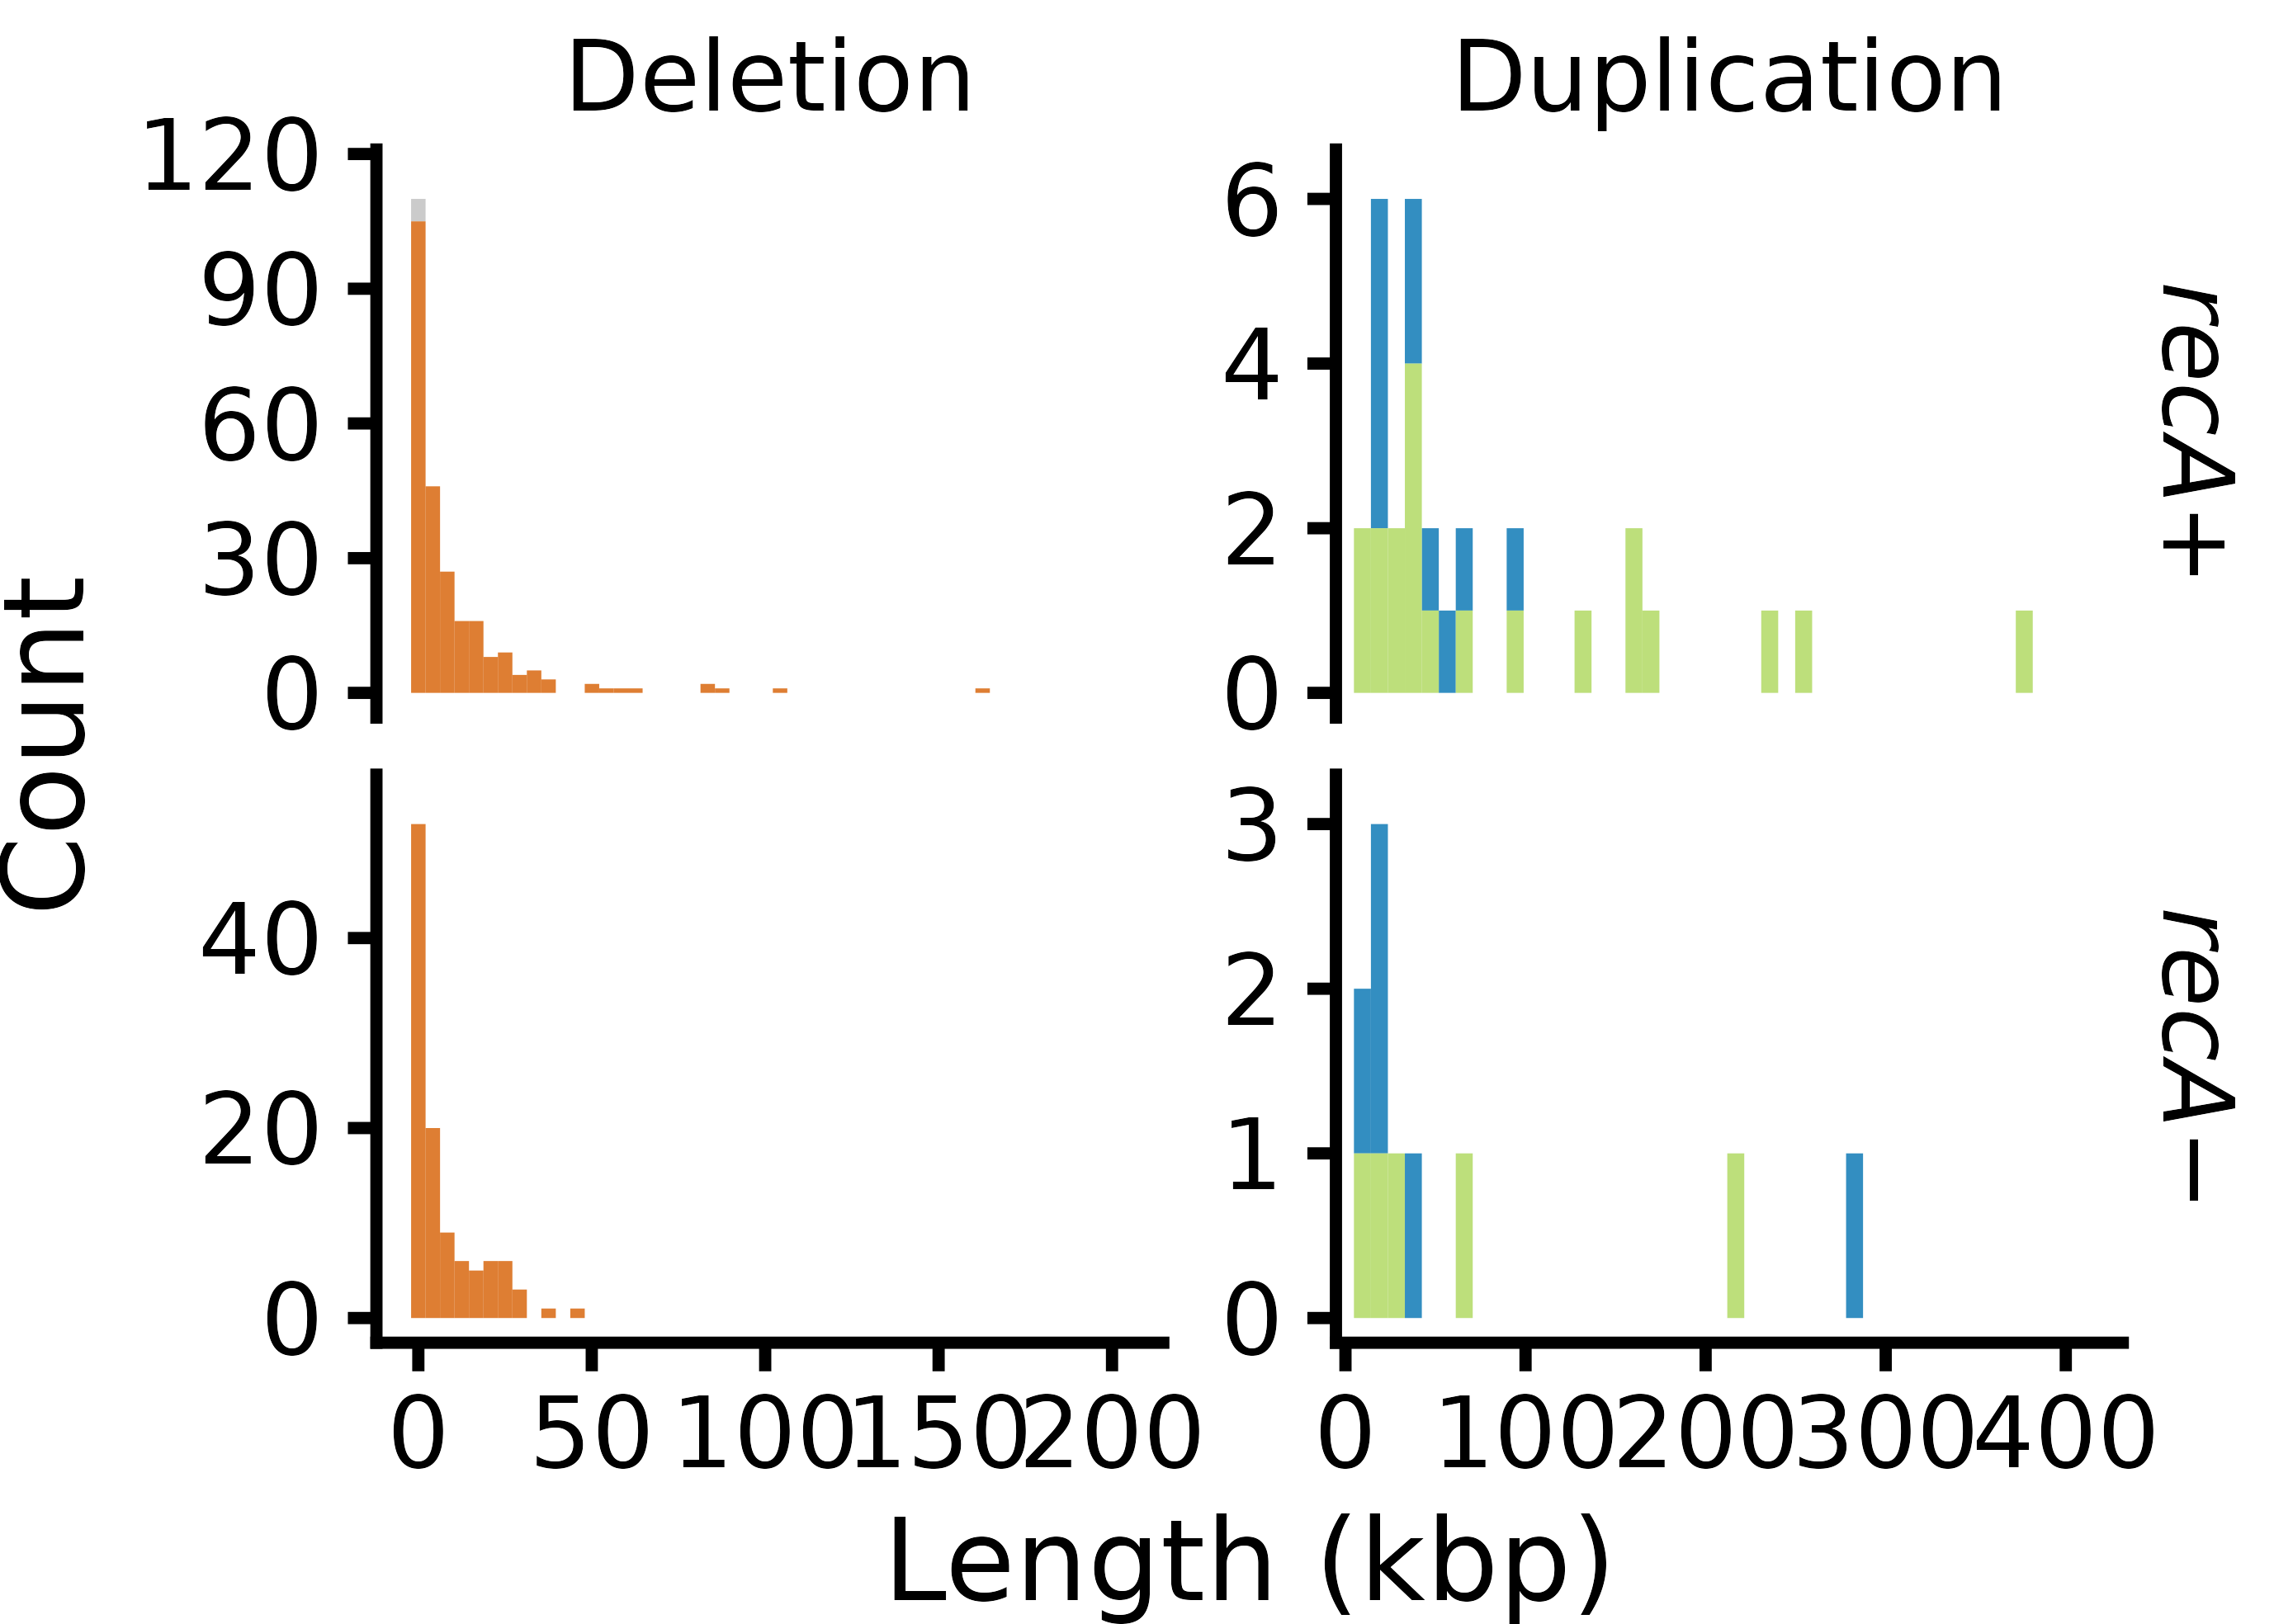

In [7]:
# based on depth interval
# unlike the plot in ipynb (02) here, I annotate which are Trans/Tandem

figure_name = file_prefix * "Del-Dup_length_histogram_ann"
@rput figure_name
R"""
library(ggh4x)
cpset1 <- RColorBrewer::brewer.pal(8, "Set1")
p <- 
depth_interval_df.evo.del %>%
	rbind(depth_interval_df.evo.annotated.dup) %>%
ggplot(aes(x = length/1e3)) +
geom_histogram(aes(fill = dup_type), bins = 40, position = "stack", alpha = 0.8) +
scale_fill_manual(values = c("grey", "#d65e00cc", "#0072b2ff", "#add75bff", "grey")) +
facet_grid2(RecA~Type, scale= "free", independent = "y", labeller = label_bquote(italic(.(RecA)), .(Type))) +
theme_half_open(10) +
scale_y_continuous(expand = expand_scale(mult = c(.05, .1))) +
scale_x_continuous(expand = expand_scale(add = c(10, 50))) +
labs(x = "Length (kbp)", y = "Count") +
theme(strip.background = element_blank(), legend.position = "none", plot.margin = unit(c(0,0,0,0), "cm"))

saveRDS(p, paste0(figure_export_dir,"/", figure_name, ".rds"))

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=70, height=50, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=70, height=50, units="mm", dpi=1000, device = cairo_pdf)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=70, height=50, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

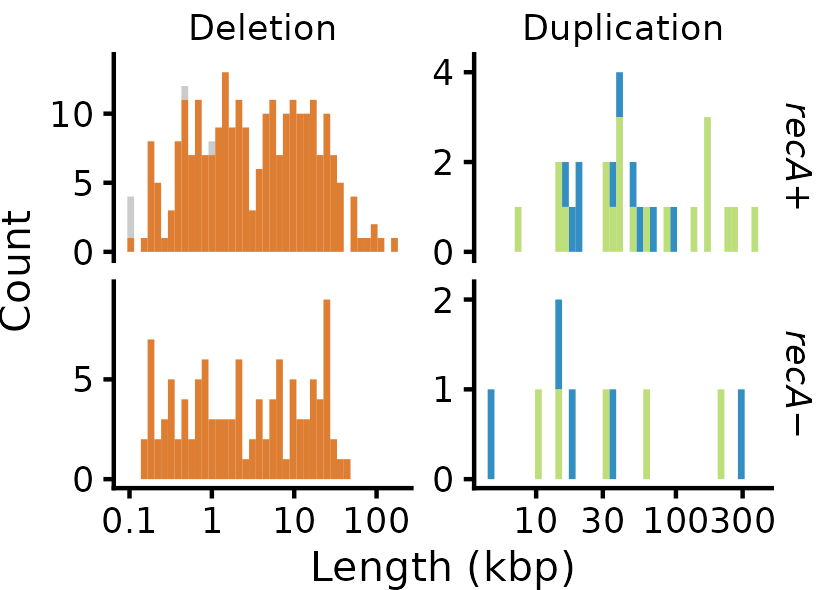

In [8]:
# based on depth interval
# unlike the plot in ipynb (02) here, I annotate which are Trans/Tandem

figure_name = file_prefix * "Del-Dup_length_histogram_ann_xlog"
@rput figure_name
R"""
library(ggh4x)
cpset1 <- RColorBrewer::brewer.pal(8, "Set1")
p <- 
depth_interval_df.evo.del %>%
	rbind(depth_interval_df.evo.annotated.dup) %>%
ggplot(aes(x = length/1e3)) +
geom_histogram(aes(fill = dup_type), bins = 40, position = "stack", alpha = 0.8) +
scale_fill_manual(values = c("grey", "#d65e00cc", "#0072b2ff", "#add75bff", "grey")) +
facet_grid2(RecA~Type, scale= "free", independent = "y", labeller = label_bquote(italic(.(RecA)), .(Type))) +
theme_half_open(10) +
scale_y_continuous(expand = expand_scale(mult = c(.05, .1)),
	breaks = pretty_breaks(n = 3)) +
#scale_x_log10(breaks = pretty_breaks(n = 4)) +
scale_x_log10(labels = scales::label_number(drop0trailing = TRUE)) +
labs(x = "Length (kbp)", y = "Count") +
theme(strip.background = element_blank(), legend.position = "none", plot.margin = unit(c(0,0,0,0), "cm"))

saveRDS(p, paste0(figure_export_dir,"/", figure_name, ".rds"))

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=70, height=50, units="mm", dpi=300)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=70, height=50, units="mm", dpi=1000, device = cairo_pdf)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=70, height=50, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

## Randomly generate power law

In [9]:
# closest_distances
is_closest_ess_df = CSV.read(joinpath(data_export_dir, file_prefix * "closest_essential_genes.csv"), DataFrame)
first(is_closest_ess_df, 5)

Row,Column1,start,end,IS_strand,max_alignment_length,length,cluster_id,line,gen_id,closest_gene_5_prime,position_5_prime,distance_5_prime,closest_gene_3_prime,position_3_prime,distance_3_prime
,Int64,Int64,Int64,String7,Int64,Int64,Int64,String7,Int64,String7,Int64,Int64,String7,Int64,Int64
1,0,476928,480020,reverse,3093,3093,0,L01-1,1,yjeE,470186,6742,rpsR,503080,23060
2,1,557167,560259,reverse,3093,3093,1,L01-1,1,ppa,526892,30275,valS,561324,1065
3,2,1187831,1192502,forward,3093,4672,2,L01-1,1,leuS,1175771,12060,asnS,1205042,12540
4,3,1405123,1408215,forward,3093,3093,3,L01-1,1,infA,1266184,138939,fldA,1476321,68106
5,4,1499230,1503892,reverse,3093,4663,4,L01-1,1,lnt,1496376,2854,fabA,1519050,15158


In [10]:
@rput is_closest_ess_df
R"""
is_closest_ess_df %>% group_by(line, gen_id) %>% 
	summarise(dist_5 = mean(distance_5_prime), dist_3 = mean(distance_3_prime),
		dist5.med = median(distance_5_prime), dist3.med = median(distance_3_prime)
	) %>%
	ungroup %>%
	mutate(w = ifelse(gen_id == 1, 8, 12)) %>%
	summarise(w.sum = sum(w), dist.mean = sum(w*(dist_3 + dist_5)/2)/w.sum,
	 		dist.med = sum(w*(dist5.med + dist3.med))/w.sum/2)
"""

┌ Warning: RCall.jl: `summarise()` has grouped output by 'line'. You can override using the
│ `.groups` argument.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 1 × 3
  w.sum dist.mean dist.med
  <dbl>     <dbl>    <dbl>
1  1408    41219.   23692.


In [11]:
using Distributions

seed = 1
rng = Xoshiro(seed)

res = []
n_iter = 100001
min_val = 200

#res = rand(rng, Pareto(0, min_val), n_iter)
res = rand(rng, LogUniform(min_val, 1e6), n_iter)
res = round.(Int, res)
res[1:5]

5-element Vector{Int64}:
    374
   3916
  76908
  42166
 484535

In [12]:
valid_res = repeat([1], n_iter)
lines = is_closest_ess_df.line |> unique |> collect

for i in 1:n_iter
	rounds = rand(rng, 1:20)
	gen_id = rounds <= 8 ? 1 : 2 
	line = rand(rng, lines)
	rows = @chain is_closest_ess_df begin
		@subset(:line .== line, :gen_id .== gen_id)
	end
	n_row = nrow(rows)
	is_idx = rand(rng, 1:n_row)
	side = rand(rng, [5,3])
	if side == 5
		valid_res[i] = rows.distance_5_prime[is_idx] >= res[i]
	else
		valid_res[i] = rows.distance_3_prime[is_idx] >= res[i]
	end
end
res_sub = res[valid_res .== 1]
length(res_sub)

54299

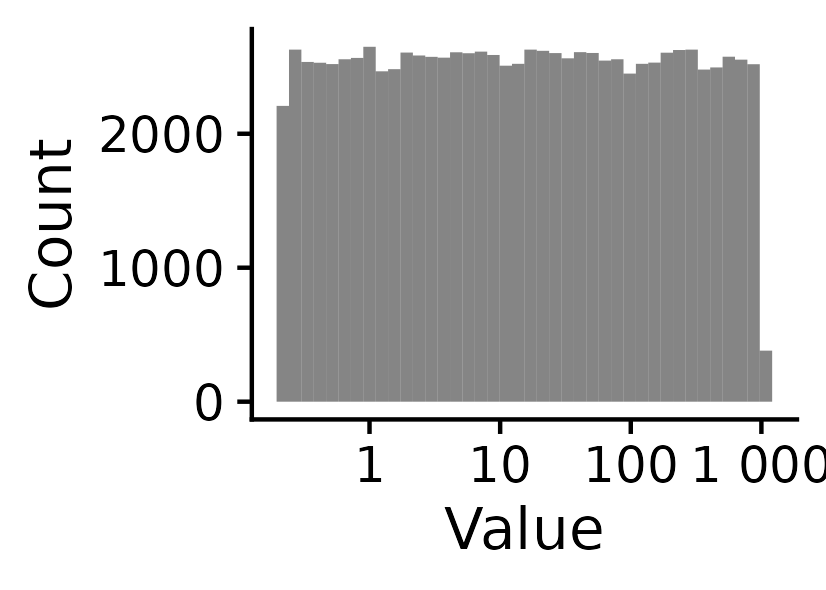

In [13]:
@rput res
figure_name = file_prefix * "log-uniform"
@rput figure_name

R"""
p <- 
data.frame(Value = res) %>%
ggplot(aes(x = Value/1e3)) +
  geom_histogram(bins = 40, fill = "grey20", alpha = 0.6) +
  theme_half_open() +
  scale_x_log10(labels = scales::label_number(drop0trailing = TRUE)) +
  labs(x = "Value", y = "Count")

p.log.uniform <- p

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=70, height=50, units="mm", dpi=300)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=70, height=50, units="mm", dpi=1000, device = cairo_pdf)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=70, height=50, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

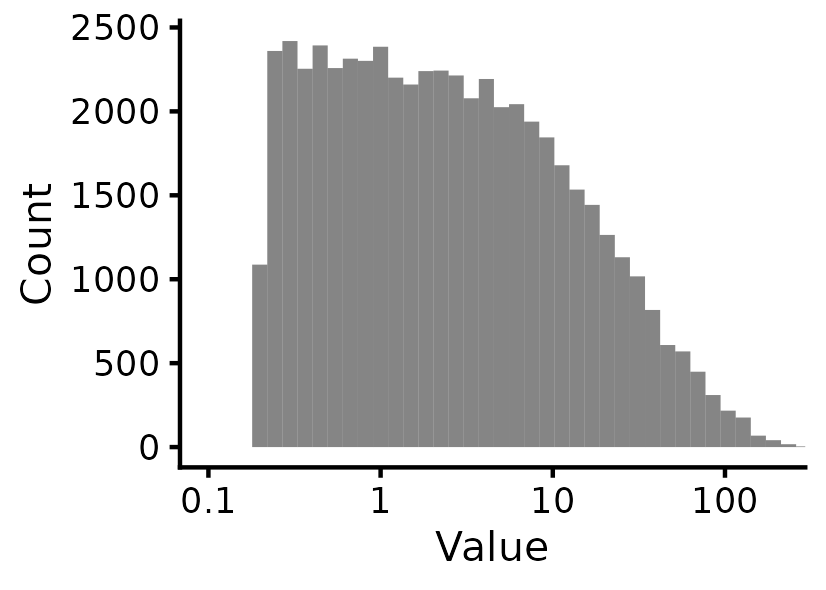

In [14]:
figure_name = file_prefix * "log-uniform_cutoff"
@rput figure_name
@rput res_sub
R"""
p <- 
data.frame(Value = res_sub) %>%
ggplot(aes(x = Value/1e3)) +
  geom_histogram(bins = 40, fill = "grey20", alpha = 0.6) +
  theme_half_open(10) +
  scale_x_log10(labels = scales::label_number(drop0trailing = TRUE)) +
  coord_cartesian(xlim = c(0.1, 2e2)) +
  #labs(title = "log-uniform with cutoff", x = "Value", y = "Count")
  labs(x = "Value", y = "Count")

p.log.cutoff <- p 

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=70, height=50, units="mm", dpi=300)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=70, height=50, units="mm", dpi=1000, device = cairo_pdf)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=70, height=50, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

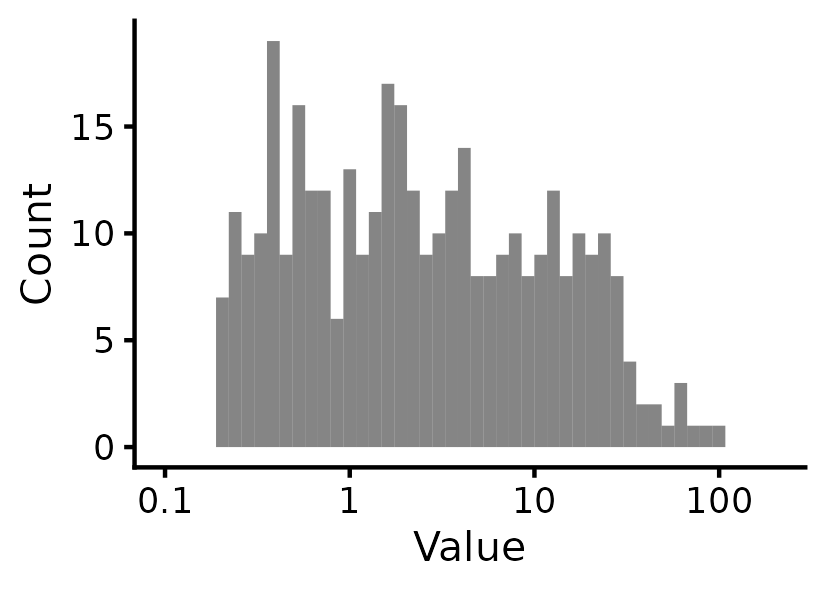

In [33]:
figure_name = file_prefix * "log-uniform_cutoff_subset"
@rput figure_name
@rput res_sub
R"""
set.seed(123)
p <- 
data.frame(Value = res_sub) %>%
sample_n(358) %>%
ggplot(aes(x = Value/1e3)) +
  geom_histogram(bins = 40, fill = "grey20", alpha = 0.6) +
  theme_half_open(10) +
  scale_x_log10(labels = scales::label_number(drop0trailing = TRUE)) +
  coord_cartesian(xlim = c(0.1, 2e2)) +
  labs(x = "Value", y = "Count")

p.log.cutoff.subset <- p

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=70, height=50, units="mm", dpi=300)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=70, height=50, units="mm", dpi=1000, device = cairo_pdf)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=70, height=50, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

In [16]:
res_sub_log = copy(res_sub);

In [25]:
using Distributions

seed = 1
rng = Xoshiro(seed)

res = []
n_iter = 100000
min_val = 200

#res = rand(rng, Pareto(0, min_val), n_iter)
#res = rand(rng, LogUniform(min_val, 4e6), n_iter)
res = rand(rng, 20: 3e5, n_iter)
res = round.(Int, res)
res[1:5]

5-element Vector{Int64}:
  22028
 104785
 209654
 188487
 274481

In [26]:
valid_res = repeat([1], n_iter)
lines = is_closest_ess_df.line |> unique |> collect

for i in 1:n_iter
	rounds = rand(rng, 1:20)
	gen_id = rounds <= 8 ? 1 : 2 
	line = rand(rng, lines)
	rows = @chain is_closest_ess_df begin
		@subset(:line .== line, :gen_id .== gen_id)
	end
	n_row = nrow(rows)
	is_idx = rand(rng, 1:n_row)
	side = rand(rng, [5,3])
	if side == 5
		valid_res[i] = rows.distance_5_prime[is_idx] >= res[i]
	else
		valid_res[i] = rows.distance_3_prime[is_idx] >= res[i]
	end
end
res_sub = res[valid_res .== 1]
length(res_sub)

13526

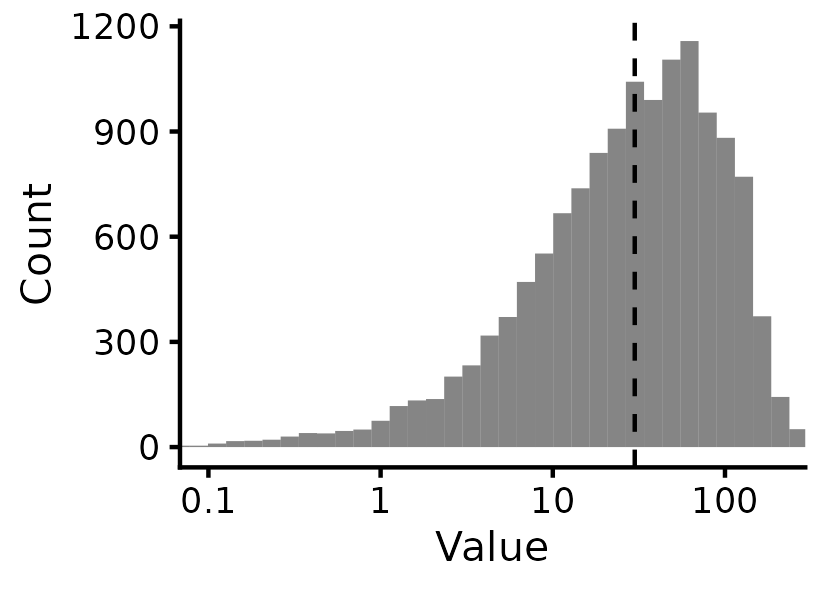

In [27]:
figure_name = file_prefix * "uniform_cutoff"
@rput figure_name
@rput res_sub
R"""
p <- 
data.frame(Value = res_sub) %>%
ggplot(aes(x = Value/1e3)) +
  geom_histogram(bins = 40, fill = "grey20", alpha = 0.6) +
  theme_half_open(10) +
  scale_x_log10(labels = scales::label_number(drop0trailing = TRUE)) +
  coord_cartesian(xlim = c(0.1, 2e2)) +
  #labs(title = "log-uniform with cutoff", x = "Value", y = "Count")
  geom_vline(xintercept = 29915.982584326164/1e3, linetype = "dashed", color = "black") +
  labs(x = "Value", y = "Count")

p.uniform.cutoff <- p 

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=70, height=50, units="mm", dpi=300)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=70, height=50, units="mm", dpi=1000, device = cairo_pdf)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=70, height=50, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

In [29]:
median(res_sub) # slightly different from expected

31283.0

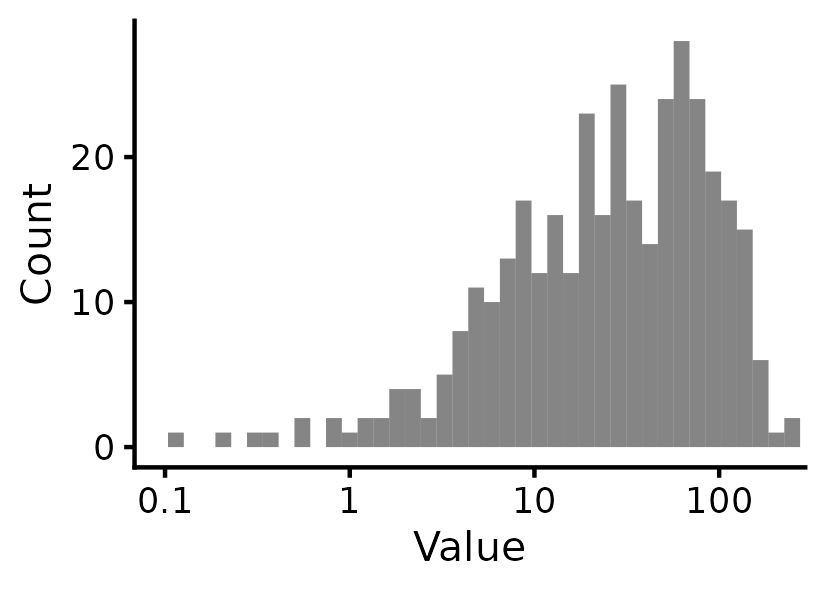

In [30]:
figure_name = file_prefix * "uniform_cutoff_subset"
@rput figure_name
R"""
set.seed(123)
p <- 
data.frame(Value = res_sub) %>%
sample_n(358) %>%
ggplot(aes(x = Value/1e3)) +
  geom_histogram(bins = 40, fill = "grey20", alpha = 0.6) +
  theme_half_open(10) +
  scale_x_log10(labels = scales::label_number(drop0trailing = TRUE)) +
  coord_cartesian(xlim = c(0.1, 2e2)) +
  labs(x = "Value", y = "Count")

p.uniform.cutoff.subset <- p

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=70, height=50, units="mm", dpi=300)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=70, height=50, units="mm", dpi=1000, device = cairo_pdf)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=70, height=50, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

In [21]:
res_sub_uniform = copy(res_sub);

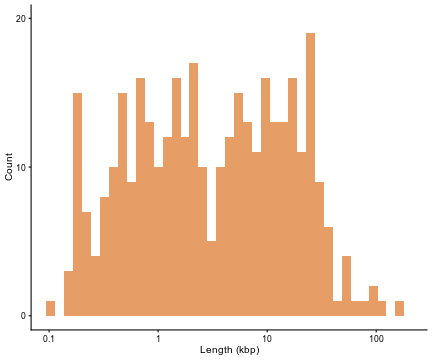

RObject{VecSxp}


In [22]:
R"""
p.del.only.is <-
depth_interval_df.evo.del %>%
	filter(dup_type == "IS") %>%
ggplot(aes(x = length/1e3)) +
  geom_histogram(bins = 40, fill = "#d65e00cc", alpha = 0.6) +
theme_half_open(10) +
scale_y_continuous(expand = expand_scale(mult = c(.05, .1)),
	breaks = pretty_breaks(n = 3)) +
  coord_cartesian(xlim = c(0.1, 2e2)) +
scale_x_log10(labels = scales::label_number(drop0trailing = TRUE)) +
labs(x = "Length (kbp)", y = "Count")
"""

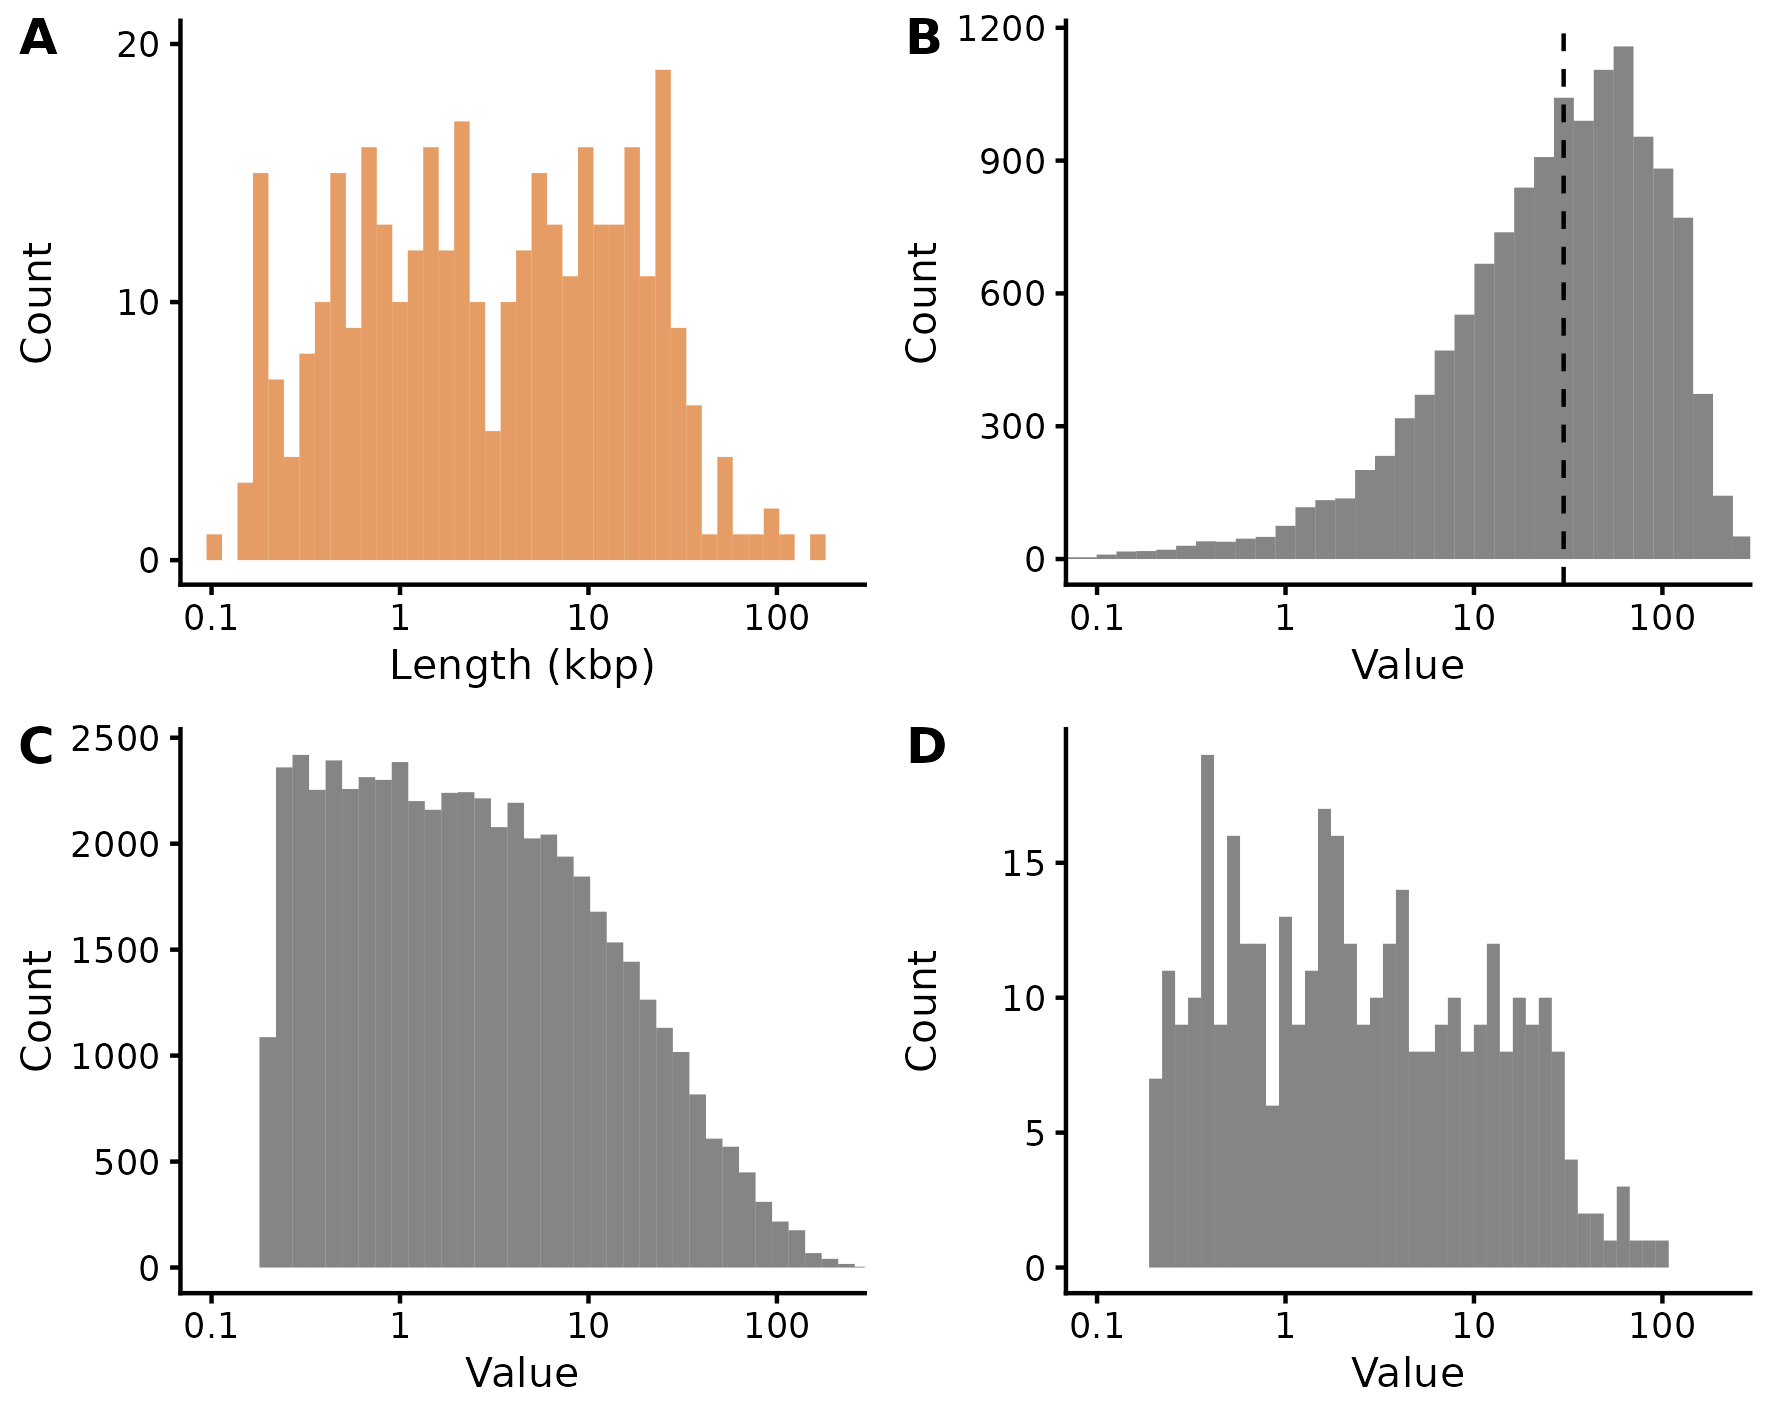

In [34]:
figure_name = file_prefix * "del_dist_merged_uni"
@rput figure_name
R"""
p <- 
plot_grid(p.del.only.is, p.uniform.cutoff, p.log.cutoff, p.log.cutoff.subset,
	nrow = 2, ncol = 2, labels = c("A", "B", "C", "D"), label_size = 12,
	rel_heights = c(1, 1), align = "hv") 

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=150, height=120, units="mm", dpi=300)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=150, height=120, units="mm", dpi=1000, device = cairo_pdf)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=150, height=120, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

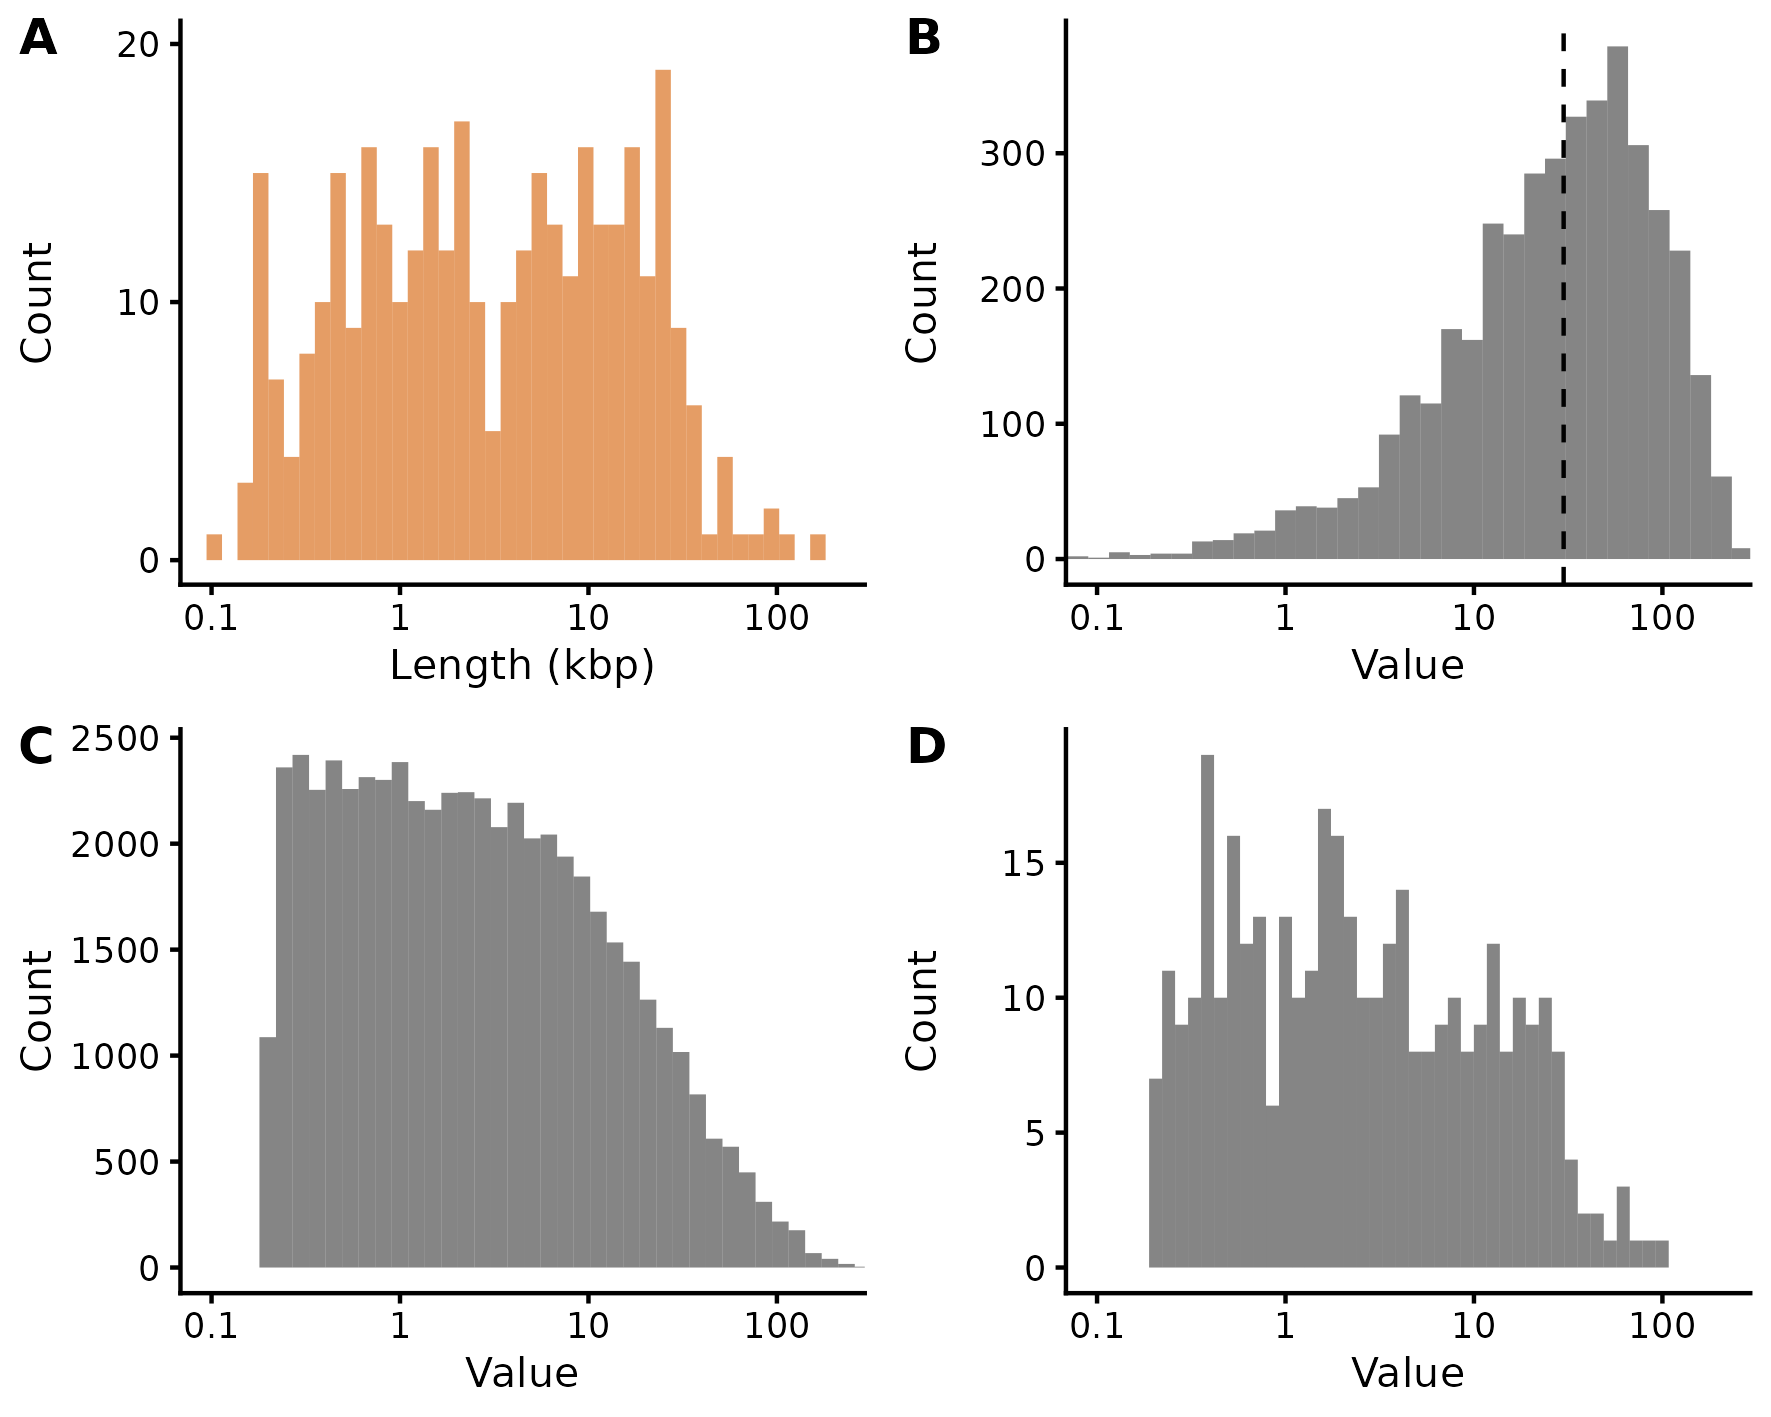

In [24]:
figure_name = file_prefix * "del_dist_merged_uni-log-sub"
@rput figure_name
R"""
p <- 
plot_grid(p.del.only.is, p.uniform.cutoff, p.log.cutoff, p.log.cutoff.subset,
	nrow = 2, ncol = 2, labels = c("A", "B", "C", "D"), label_size = 12,
	rel_heights = c(1, 1), align = "hv") 

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=150, height=120, units="mm", dpi=300)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=150, height=120, units="mm", dpi=1000, device = cairo_pdf)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=150, height=120, units="mm", dpi=1000)
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

## DUP stat

In [9]:
R"""
depth_interval_df.evo.annotated.dup %>%
	summarise(Max = max(length), Min = min(length), Mean = mean(length), Median = median(length), SD = sd(length))
	"""

RObject{VecSxp}
# A tibble: 1 × 5
     Max   Min   Mean Median     SD
   <dbl> <dbl>  <dbl>  <dbl>  <dbl>
1 372360  4830 77133.  39957 88954.


## Stat IS in IS
Is the numer more than expected?

First I analyzed using whole genome.

In [10]:
R"""
genome_stats_df <- read_csv(file.path(base_dir_event_classification, "genome_stats_merged.csv"))
genome_stats_df %>% head
"""

┌ Warning: RCall.jl: Rows: 132 Columns: 31
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: ","
│ chr  (8): IS_Detect_ID, gen, file_name, Anc, Prefix, sample_name_raw, Contig...
│ dbl (22): ParentLine, SubLine, RecA, gen_id, genome_size, is_cnt, is_length,...
│ lgl  (1): Complete
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 6 × 31
  IS_Detect_ID ParentLine SubLine gen   file_name             Anc    RecA Prefix
  <chr>             <dbl>   <dbl> <chr> <chr>                 <chr> <dbl> <chr> 
1 L01_Anc               1       1 FACS  20231004/L01_Anc_m1.… R01       1 L01-1 
2 L01_Anc               1       2 FACS  20231004/L01_Anc_m1.… R01       1 L01-2 
3 L01_Anc               1       3 FACS  20231004/L01_Anc_m1.… R01       1 L01-3 
4 L01_Anc               1       4 FACS  20231004/L01_Anc_m1.… R01       1 L01-4 
5 L02_Anc               2       1 FACS  20231003/L02_Anc.fas… R02       1 L02-1 
6 L02_Anc               2       2 FACS  20231003/L02_Anc.fas… R02       1 L02-2 
# ℹ 23 more variables: sample_name_raw <chr>, Contig_Date <chr>,
#   Complete <lgl>, gen_id <dbl>, File <chr>, genome_size <dbl>, is_cnt <dbl>,
#   is_length <dbl>, ins_pos_cnt_raw <dbl>, ins_pos_cnt <dbl>, new_cnt <dbl>,
#   lost_end_cnt <dbl>, simple_insertion_cnt <dbl>, ins_pos_cnt_raw_anc <dbl>,
#   ins_pos_cnt_

In [11]:
# proportion of IS in the genome
R"""
genome_stats_df %>%group_by(gen_id) %>%
	summarise(IS_len = mean(is_length), genome_len = mean(genome_size)) %>%
	mutate(IS_prop = IS_len/genome_len) 
"""

RObject{VecSxp}
# A tibble: 3 × 4
  gen_id IS_len genome_len IS_prop
   <dbl>  <dbl>      <dbl>   <dbl>
1      1 38567.   3987215. 0.00967
2      2 60991.   4008591. 0.0152 
3      3 76835.   4018747. 0.0191 


In [12]:
260 * 0.00967

2.5141999999999998

I should have analyzed with non-essential length

In [13]:
R"""
ess_gene_pos <- read_csv(file.path(data_export_dir, paste0(file_prefix, "essential_gene_pos.csv")))
ess_gene_pos %>% head
"""

┌ Warning: RCall.jl: Rows: 40055 Columns: 15
│ ── Column specification ────────────────────────────────────────────────────────
│ Delimiter: ","
│ chr  (2): gene, line
│ dbl (12): pident, length, mismatch, gapopen, qstart, qend, sstart, send, eva...
│ lgl  (1): duplicated
│ 
│ ℹ Use `spec()` to retrieve the full column specification for this data.
│ ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 6 × 15
  gene  pident length mismatch gapopen qstart  qend  sstart    send evalue
  <chr>  <dbl>  <dbl>    <dbl>   <dbl>  <dbl> <dbl>   <dbl>   <dbl>  <dbl>
1 mukB    100    4460        0       0      1  4460 1216300 1211841      0
2 rpoC    100.   4223        2       0      1  4223  259602  263824      0
3 rpoB    100    4028        0       0      1  4028  255497  259524      0
4 ftsK    100    3989        0       0      1  3989 1259403 1255415      0
5 dnaE    100    3482        0       0      1  3482  821464  824945      0
6 rne     100    3185        0       0      1  3185 1612916 1616100      0
# ℹ 5 more variables: bitscore <dbl>, qlen <dbl>, line <chr>, gen_id <dbl>,
#   duplicated <lgl>


In [14]:
R"""
ess_gene_pos %>% pull(gen_id) %>% unique
"""

RObject{RealSxp}
[1] 1 2 3


In [15]:
R"""
ness_genome_stat <-
ess_gene_pos %>% group_by(line, gen_id) %>%
	filter(!duplicated) %>%
	summarise(ess_len = sum(length)) %>%
	select(Prefix = line, gen_id, ess_len) %>%
	left_join(genome_stats_df %>% select(Prefix, gen_id, genome_size, is_length), by = c("Prefix", "gen_id")) %>%
	mutate(ness_len = genome_size - ess_len)
ness_genome_stat %>% head
"""

┌ Warning: RCall.jl: `summarise()` has grouped output by 'line'. You can override using the
│ `.groups` argument.
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{VecSxp}
# A tibble: 6 × 6
# Groups:   Prefix [2]
  Prefix gen_id ess_len genome_size is_length ness_len
  <chr>   <dbl>   <dbl>       <dbl>     <dbl>    <dbl>
1 L01-1       1  308424     4003851     38786  3695427
2 L01-1       2  308423     4051419     61995  3742996
3 L01-1       3  308422     3923637    102740  3615215
4 L01-2       1  308424     4003851     38786  3695427
5 L01-2       2  307147     4007666     55756  3700519
6 L01-2       3  307146     3978375     71226  3671229


In [16]:
R"""
ness_genome_stat %>% pull(ess_len) %>% summary
"""

RObject{RealSxp}
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 285420  308421  308422  306851  308424  308635 


In [17]:
R"""
ness_genome_stat %>% arrange(ess_len) %>% head
"""

RObject{VecSxp}
# A tibble: 6 × 6
# Groups:   Prefix [5]
  Prefix gen_id ess_len genome_size is_length ness_len
  <chr>   <dbl>   <dbl>       <dbl>     <dbl>    <dbl>
1 L11-4       3  285420     4248613     92682  3963193
2 L02-1       3  288778     4175720    106545  3886942
3 L02-2       3  289382     4396104     91573  4106722
4 L10-3       3  290541     4030092     84193  3739551
5 L08-3       2  292136     4236956     49489  3944820
6 L08-3       3  292144     4231221     52568  3939077


In [18]:
R""" # ok it seems to be due to duplications
ess_gene_pos %>% filter(gen_id == 3, line == "L11-4") %>%
summarise(total.cnt = n(), duplicated.cnt = sum(duplicated),
	total.len = sum(length), duplicated.len = sum(length * (duplicated)))
"""

RObject{VecSxp}
# A tibble: 1 × 4
  total.cnt duplicated.cnt total.len duplicated.len
      <int>          <int>     <dbl>          <dbl>
1       321             38    331422          46002


In [19]:
R"""
ness_genome_stat %>% group_by(gen_id) %>%
	#summarise(ess_len = mean(ess_len), ness_len = mean(ness_len), genome_size = mean(genome_size), is_length = mean(is_length)) %>%
	summarise(ess_len.mean = mean(ess_len), ness_len.mean = mean(ness_len), genome_size.mean = mean(genome_size), is_length.mean = mean(is_length),
		is_prop.mean = mean(is_length/ness_len))
"""

RObject{VecSxp}
# A tibble: 3 × 6
  gen_id ess_len.mean ness_len.mean genome_size.mean is_length.mean is_prop.mean
   <dbl>        <dbl>         <dbl>            <dbl>          <dbl>        <dbl>
1      1      308443.      3678772.         3987215.         38567.       0.0105
2      2      307245.      3701347.         4008591.         60991.       0.0165
3      3      304864.      3713882.         4018747.         76835.       0.0207


In [25]:
260 .* [0.0105, 0.0207]

2-element Vector{Float64}:
 2.73
 5.382

In [28]:
R"""
ness_genome_stat %>%
	mutate(is_prop = is_length/ness_len) %>%
	arrange(-is_prop) %>% head(20)
"""

RObject{VecSxp}
# A tibble: 20 × 7
# Groups:   Prefix [18]
   Prefix gen_id ess_len genome_size is_length ness_len is_prop
   <chr>   <dbl>   <dbl>       <dbl>     <dbl>    <dbl>   <dbl>
 1 L02-4       3  305019     4007359    110516  3702340  0.0299
 2 L04-4       3  302578     4106247    111351  3803669  0.0293
 3 L05-2       3  308422     3938244    104538  3629822  0.0288
 4 L01-1       3  308422     3923637    102740  3615215  0.0284
 5 L02-1       3  288778     4175720    106545  3886942  0.0274
 6 L10-4       3  308456     4074199     99353  3765743  0.0264
 7 L06-2       3  308422     3988727     94701  3680305  0.0257
 8 L05-4       3  308422     3954835     92771  3646413  0.0254
 9 L03-4       3  305019     4041838     92769  3736819  0.0248
10 L04-3       3  301271     4165763     95869  3864492  0.0248
11 L04-2       3  308422     3914267     88035  3605845  0.0244
12 L02-4       2  308423     3961175     87166  3652752  0.0239
13 L03-3       3  308422     3910841     8547

In [30]:
R""" # Note there is the confounding factor of the additional IS
ness_genome_stat %>%
	ungroup %>%
	mutate(is_prop = is_length/ness_len) %>%
	arrange(-is_prop) %>%
	mutate(ID = row_number()) %>%
	#2-1, 5-1, 6-2, 10-4
	filter(gen_id == 3, Prefix %in% c("L02-1", "L05-1", "L06-2", "L10-4")) 
"""

RObject{VecSxp}
# A tibble: 4 × 8
  Prefix gen_id ess_len genome_size is_length ness_len is_prop    ID
  <chr>   <dbl>   <dbl>       <dbl>     <dbl>    <dbl>   <dbl> <int>
1 L02-1       3  288778     4175720    106545  3886942  0.0274     5
2 L10-4       3  308456     4074199     99353  3765743  0.0264     6
3 L06-2       3  308422     3988727     94701  3680305  0.0257     7
4 L05-1       3  308422     3943646     71279  3635224  0.0196    38


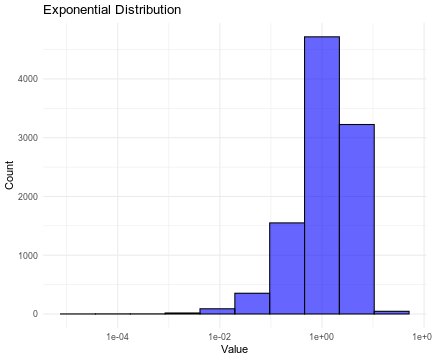

RObject{VecSxp}


In [30]:
λ = 0.5  # Rate parameter
n = 10000  # Number of samples
df = DataFrame(Value = randexp(n) / λ)

@rput df

R"""
ggplot(df, aes(x = Value)) +
  geom_histogram(bins = 10, fill = "blue", alpha = 0.6, color = "black") +
  theme_minimal() +
  scale_x_log10() +
  labs(title = "Exponential Distribution", x = "Value", y = "Count")
"""